In [14]:
import pandas as pd
from xgboost import XGBClassifier
from Encoding import one_hot_encode_dataframe, clean_alter_column
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Einlesen der synthetischen und realen Trainingsdaten

In [ ]:
df_synthetic = pd.read_csv("../data/synthetic_train_data.csv")

test_data = pd.read_csv("../data/real_test_data.csv")

real_train_data = pd.read_csv("../data/real_train_data.csv")

# Formattierung & Encoding

In [16]:
df_synthetic = clean_alter_column(df_synthetic)
real_train_data = clean_alter_column(real_train_data)
test_data = clean_alter_column(test_data)

In [17]:
columns=['geschlecht', 'bundesland', 'beruf', 'konsumhaeufigkeit']
# Train: fit encoder
encoded_df_synthetics, encoder = one_hot_encode_dataframe(df_synthetic, columns, return_encoder=True)

# Test: use same encoder
encoded_df_test = one_hot_encode_dataframe(test_data, columns, encoder=encoder)

# (Optional) Für TRTR:
encoded_df_train = one_hot_encode_dataframe(real_train_data, columns, encoder=encoder)


# Modellierung

In [18]:
xgb = XGBClassifier(objective="multi:softmax", num_class=5, use_label_encoder=False, eval_metric="mlogloss", random_state=77)
model = MultiOutputClassifier(xgb)

In [19]:
target_cols = [col for col in encoded_df_synthetics.columns if col.startswith("geschmack_")]


In [20]:
X_train = encoded_df_synthetics.drop(columns=target_cols)
y_train = encoded_df_synthetics[target_cols].astype(int) - 1

real_X_train = encoded_df_train.drop(columns=target_cols)
real_y_train = encoded_df_train[target_cols].astype(int) - 1

In [21]:

X_train = X_train.astype(float)
y_train = y_train.astype(float)

In [22]:
X_test = encoded_df_test.drop(columns=target_cols)
y_test = encoded_df_test[target_cols].astype(int) - 1




In [23]:
X_test = X_test.astype(float)
y_test = y_test.astype(float)


# XGB Modell mit realen Daten

In [24]:
# Fit the model
model.fit(real_X_train, real_y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Shift predictions and truth back to Likert scale (1–5)
y_pred_real_shifted = y_pred + 1
y_test_real_shifted = y_test + 1

# Print evaluation
for i, col in enumerate(target_cols):
    print(f"\n--- {col} ---")
    print(classification_report(y_test_shifted.iloc[:, i], y_pred_shifted[:, i], digits=3, zero_division=0))


--- geschmack_rauchig ---
              precision    recall  f1-score   support

         1.0      0.451     0.575     0.505        40
         2.0      0.509     0.560     0.533        50
         3.0      1.000     0.077     0.143        13
         4.0      0.000     0.000     0.000         4
         5.0      0.000     0.000     0.000         1

    accuracy                          0.481       108
   macro avg      0.392     0.242     0.236       108
weighted avg      0.523     0.481     0.451       108


--- geschmack_hopfig ---
              precision    recall  f1-score   support

         1.0      0.500     0.176     0.261        17
         2.0      0.444     0.200     0.276        20
         3.0      0.438     0.226     0.298        31
         4.0      0.377     0.906     0.532        32
         5.0      0.000     0.000     0.000         8

    accuracy                          0.398       108
   macro avg      0.352     0.302     0.273       108
weighted avg      0.398 

# XGB Modell mit synthetischen Daten

In [25]:
# Fit the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Shift predictions and truth back to Likert scale (1–5)
y_pred_synth_shifted = y_pred + 1
y_test_shifted = y_test + 1

# Print evaluation
for i, col in enumerate(target_cols):
    print(f"\n--- {col} ---")
    print(classification_report(y_test_shifted.iloc[:, i], y_pred_shifted[:, i], digits=3, zero_division=0))


--- geschmack_rauchig ---
              precision    recall  f1-score   support

         1.0      0.451     0.575     0.505        40
         2.0      0.509     0.560     0.533        50
         3.0      1.000     0.077     0.143        13
         4.0      0.000     0.000     0.000         4
         5.0      0.000     0.000     0.000         1

    accuracy                          0.481       108
   macro avg      0.392     0.242     0.236       108
weighted avg      0.523     0.481     0.451       108


--- geschmack_hopfig ---
              precision    recall  f1-score   support

         1.0      0.500     0.176     0.261        17
         2.0      0.444     0.200     0.276        20
         3.0      0.438     0.226     0.298        31
         4.0      0.377     0.906     0.532        32
         5.0      0.000     0.000     0.000         8

    accuracy                          0.398       108
   macro avg      0.352     0.302     0.273       108
weighted avg      0.398 

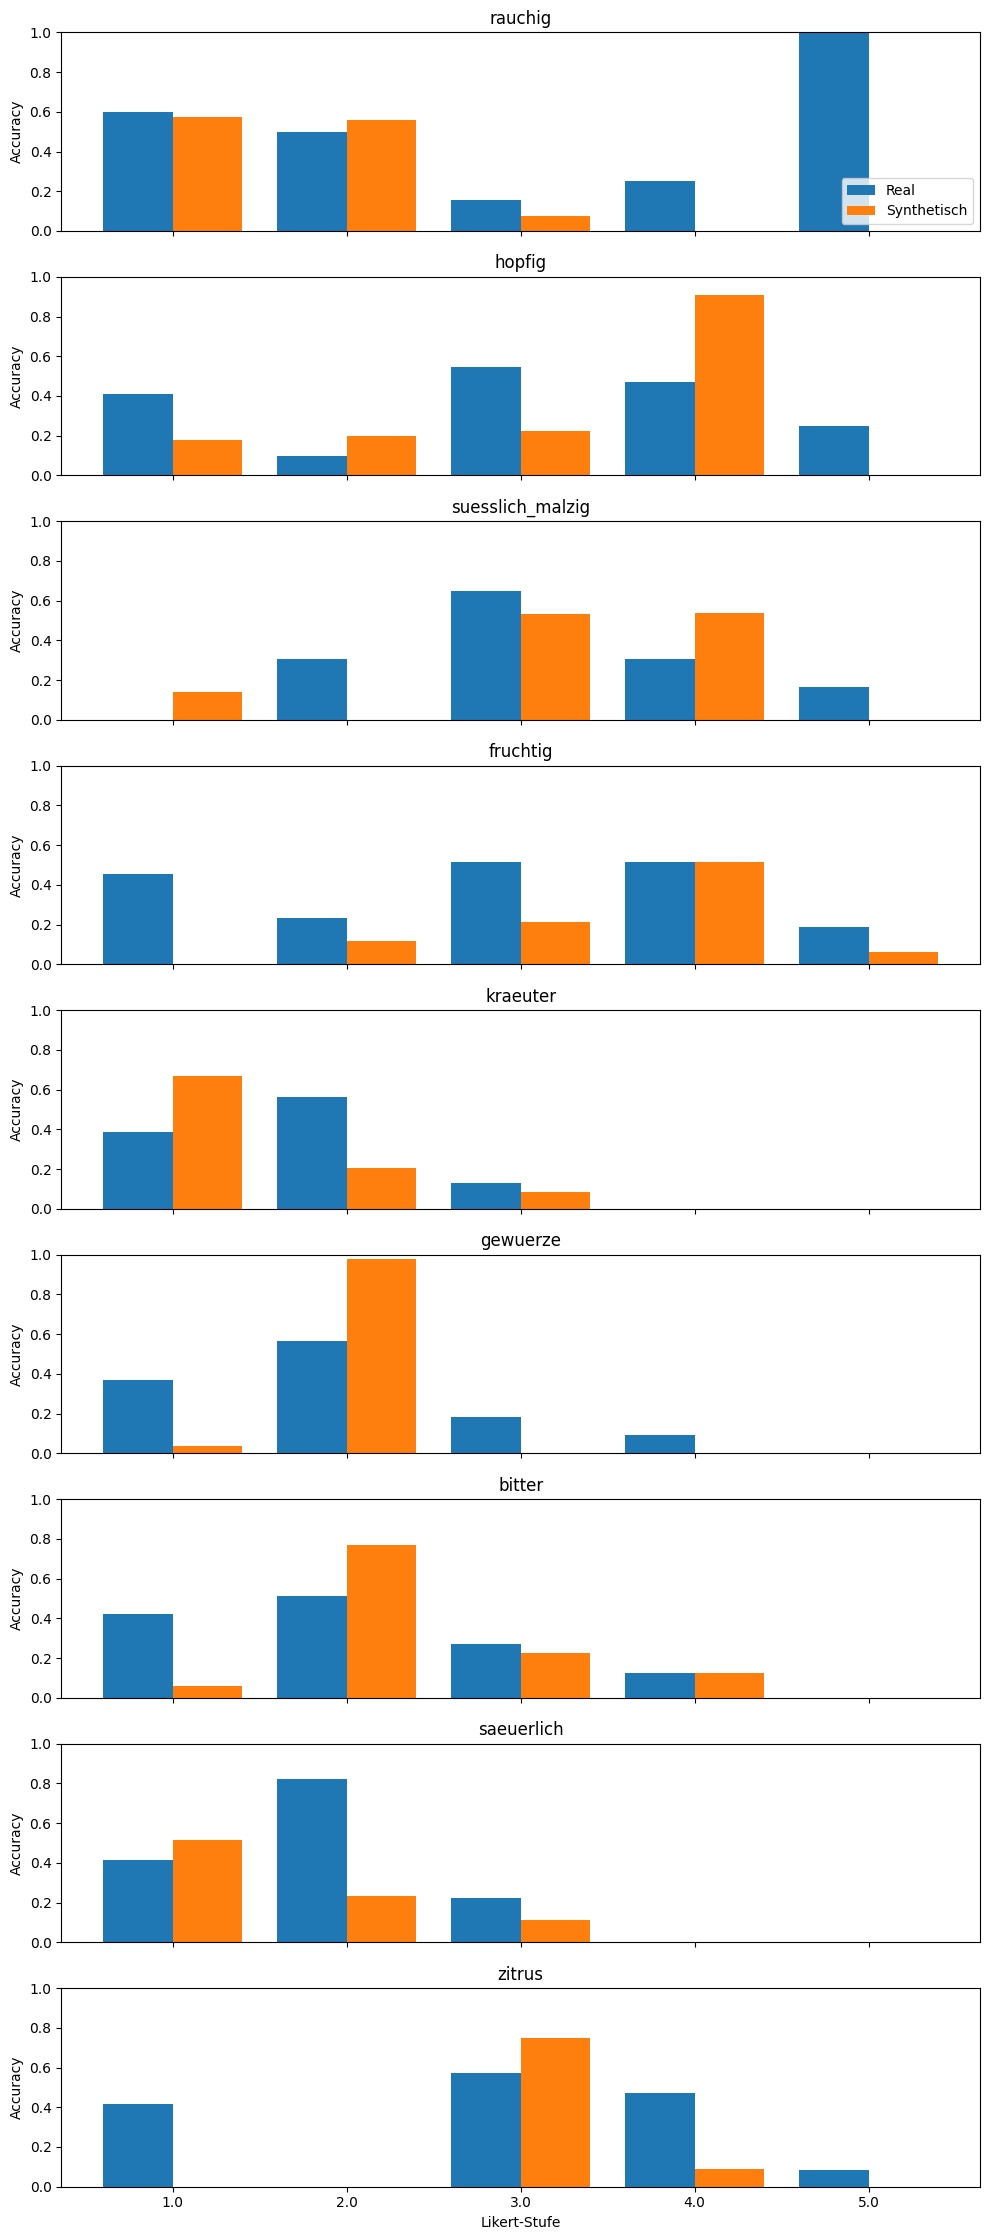

In [26]:

# Visualisierung pro Klasse
fig, axs = plt.subplots(nrows=len(target_cols), ncols=1, figsize=(10, len(target_cols)*2.5), sharex=True)

for i, col in enumerate(target_cols):
    true = y_test_shifted.iloc[:, i]
    pred_real = y_pred_real_shifted[:, i]
    pred_synth = y_pred_synth_shifted[:, i]

    class_labels = sorted(true.unique())
    acc_real = [accuracy_score(true[true == l], pred_real[true == l]) if sum(true == l) > 0 else 0 for l in class_labels]
    acc_synth = [accuracy_score(true[true == l], pred_synth[true == l]) if sum(true == l) > 0 else 0 for l in class_labels]

    x = np.arange(len(class_labels))
    axs[i].bar(x - 0.2, acc_real, width=0.4, label='Real')
    axs[i].bar(x + 0.2, acc_synth, width=0.4, label='Synthetisch')
    axs[i].set_title(col.replace("geschmack_", ""))
    axs[i].set_ylim(0, 1)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels([str(l) for l in class_labels])
    axs[i].set_ylabel("Accuracy")

axs[-1].set_xlabel("Likert-Stufe")
axs[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, cohen_kappa_score
import pandas as pd

# Leere Listen zur Speicherung der Metriken
mae_real_list = []
mae_synth_list = []
kappa_real_list = []
kappa_synth_list = []

# Berechnung für jede Zielspalte
for i, col in enumerate(target_cols):
    true = y_test_shifted.iloc[:, i]
    pred_real = y_pred_real_shifted[:, i]
    pred_synth = y_pred_synth_shifted[:, i]

    # MAE
    mae_real = mean_absolute_error(true, pred_real)
    mae_synth = mean_absolute_error(true, pred_synth)

    # Kappa (quadratisch gewichtet)
    kappa_real = cohen_kappa_score(true, pred_real, weights="quadratic")
    kappa_synth = cohen_kappa_score(true, pred_synth, weights="quadratic")

    # Speichern
    mae_real_list.append(mae_real)
    mae_synth_list.append(mae_synth)
    kappa_real_list.append(kappa_real)
    kappa_synth_list.append(kappa_synth)

# In DataFrame zusammenfassen
mae_kappa_df = pd.DataFrame({
    'Kategorie': [col.replace("geschmack_", "") for col in target_cols],
    'MAE_Real': mae_real_list,
    'MAE_Synthetisch': mae_synth_list,
    'Kappa_Real': kappa_real_list,
    'Kappa_Synthetisch': kappa_synth_list
})

# Index setzen und anzeigen
mae_kappa_df.set_index("Kategorie", inplace=True)
print(mae_kappa_df)


                  MAE_Real  MAE_Synthetisch  Kappa_Real  Kappa_Synthetisch
Kategorie                                                                 
rauchig           0.666667         0.648148    0.327360           0.098330
hopfig            0.842593         0.944444    0.490000           0.254350
suesslich_malzig  1.009259         0.962963    0.063050           0.125470
fruchtig          0.842593         1.314815    0.423030          -0.175207
kraeuter          0.787037         1.037037    0.201258           0.018096
gewuerze          0.833333         0.787037    0.171620          -0.149107
bitter            0.805556         0.777778    0.272251           0.049113
saeuerlich        0.638889         1.018519    0.107738           0.038944
zitrus            0.805556         0.925926    0.457565           0.060440


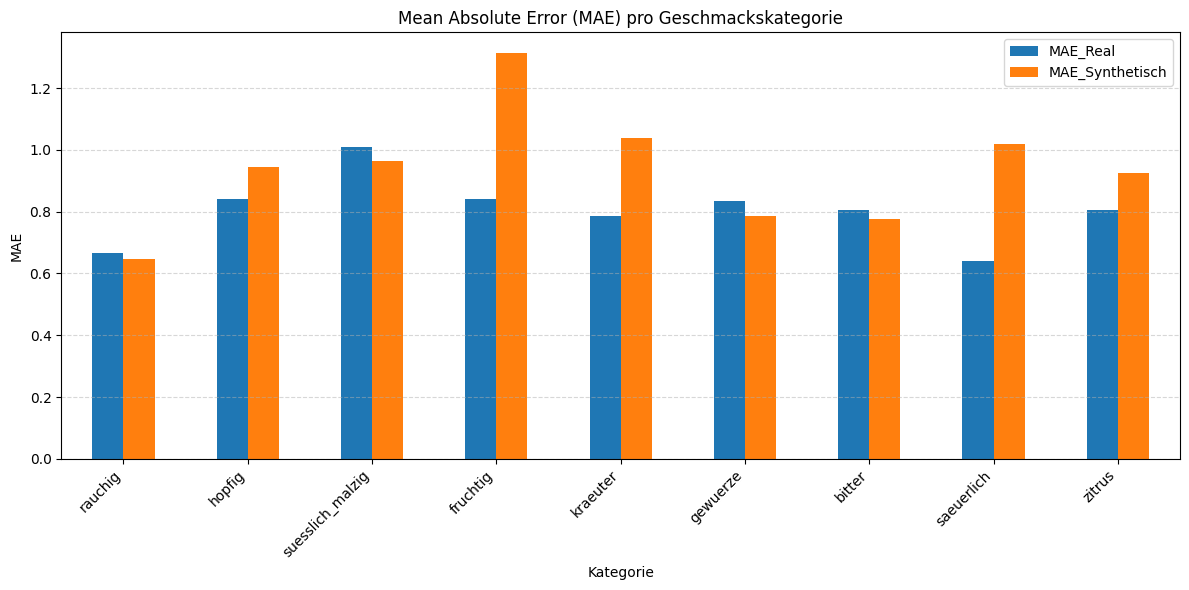

In [28]:
import matplotlib.pyplot as plt

# MAE Balkendiagramm
mae_kappa_df[["MAE_Real", "MAE_Synthetisch"]].plot(kind="bar", figsize=(12, 6))
plt.title("Mean Absolute Error (MAE) pro Geschmackskategorie")
plt.ylabel("MAE")
plt.xlabel("Kategorie")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()
